In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("../data/raw/train.csv", dtype={"StateHoliday": str})
store = pd.read_csv("../data/raw/store.csv")

print(train.shape)
print(store.shape)

(1017209, 9)
(1115, 10)


In [4]:
train.info()
train.isnull()

store.info()
store.isnull()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB
<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
1110,False,False,False,False,False,False,False,False,False,False
1111,False,False,False,False,False,False,False,True,True,True
1112,False,False,False,False,True,True,False,True,True,True
1113,False,False,False,False,True,True,False,True,True,True


In [5]:
train = train.merge(store, on="Store", how="left")
train.shape

(1017209, 18)

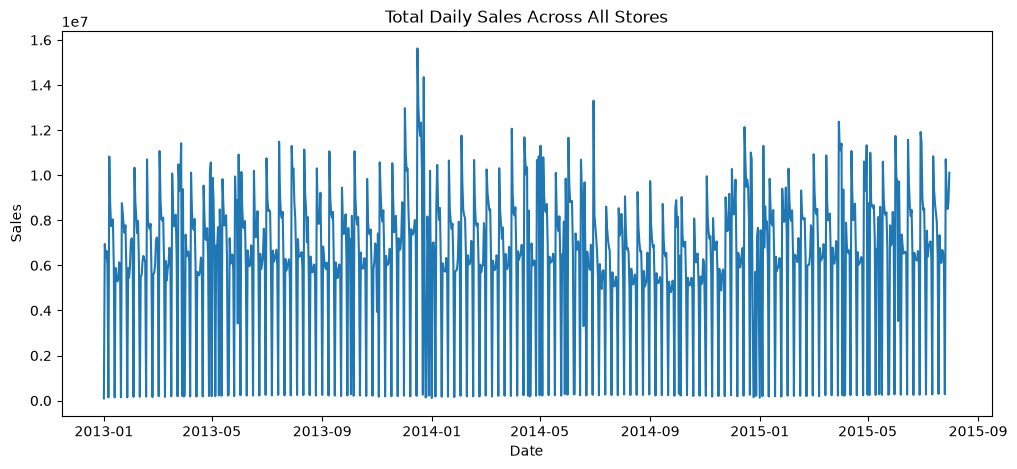

In [6]:
daily_sales = train.groupby("Date")["Sales"].sum().reset_index()
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title("Total Daily Sales Across All Stores")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

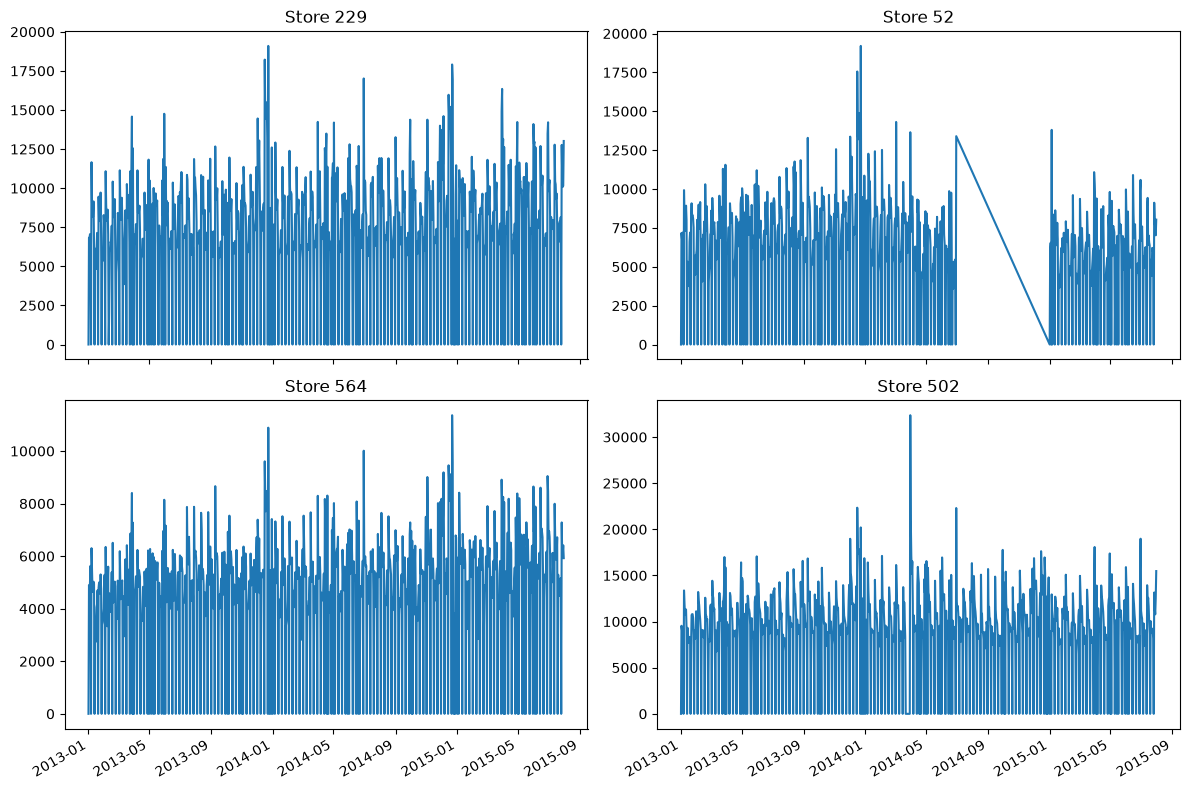

In [9]:
import random
random.seed(42)
sample_stores = random.sample(list(train["Store"].unique()), 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, store_id in zip(axes.flatten(), sample_stores):
    subset = train[train["Store"] == store_id].copy()
    subset["Date"] = pd.to_datetime(subset["Date"])
    subset = subset.sort_values("Date")
    ax.plot(subset["Date"], subset["Sales"])
    ax.set_title(f"Store {store_id}")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [10]:
#Investigating store 502's gap
subset = train[train["Store"] == 502].copy()
subset["Date"] = pd.to_datetime(subset["Date"])
subset = subset.sort_values("Date")

#Checking for gaps in the date sequence
gaps = subset["Date"].diff()
gaps[gaps > pd.Timedelta(days=1)]

Series([], Name: Date, dtype: timedelta64[us])

In [15]:
subset[(subset["Date"] >= "2014-07-01") & (subset["Date"] <= "2015-01-31")][["Date", "Open", "Sales"]].query("Open ==0")

,Date,Open,Sales
403230,2014-07-06,0,0
396685,2014-07-13,0,0
390140,2014-07-20,0,0
383595,2014-07-27,0,0
377050,2014-08-03,0,0
370505,2014-08-10,0,0
363960,2014-08-17,0,0
357415,2014-08-24,0,0
350870,2014-08-31,0,0
344325,2014-09-07,0,0


Initial visual inspection suggested an extended closure for this store; closer inspection showed this is a normal, regularly Sunday-closed store, and the apparent "closure" was a rendering artifact from viewing a full multi-year series at a compressed scale, not a real data anomaly.

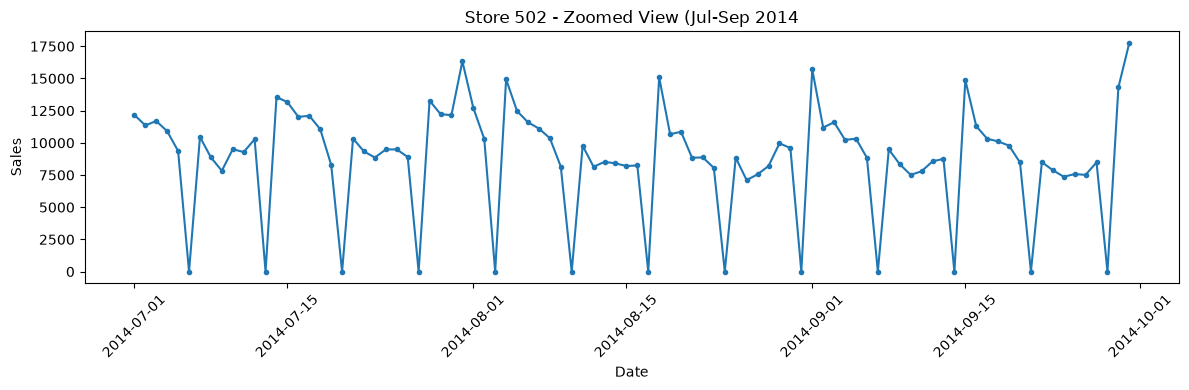

In [17]:
zoom = subset[(subset["Date"] >= "2014-07-01") & (subset["Date"] <= "2014-09-30")]

plt.figure(figsize=(12, 4))
plt.plot(zoom["Date"], zoom["Sales"], marker='o', markersize=3)
plt.title("Store 502 - Zoomed View (Jul-Sep 2014")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A closer look at the apparent "extended closure" seen in the compressed full-series view revealed a normal, regularly Sunday-closed store — not an anomaly. This is a useful reminder that visual patterns at a compressed timescale can be misleading, and worth verifying at higher resolution before drawing conclusions.